In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [3]:
# Cell 2: Load data
df = pd.read_csv('../data/raw/pakistan_used_cars.csv')
df.head()

,addref,city,assembly,body,make,model,year,engine,transmission,fuel,color,registered,mileage,price
0,7943732,Peshawar,NaN,Sedan,Toyota,Corolla,2013.0,1300.0,Manual,Petrol,Silver Metallic,Lahore,145000,2870000.0
1,7730314,Lahore,NaN,Sedan,Honda,City,2000.0,1300.0,Manual,Petrol,Blue,Lahore,230000,995000.0
2,7943737,Lahore,NaN,Sedan,Toyota,Yaris,2021.0,1300.0,Manual,Petrol,Super White,Punjab,60500,3585000.0
3,7943733,Lahore,NaN,Hatchback,Suzuki,Swift,2017.0,1300.0,Manual,Petrol,Grey,Islamabad,87000,2250000.0
4,7923484,Lahore,NaN,Sedan,Honda,Civic,2017.0,1800.0,Automatic,Petrol,Grey,Lahore,86000,4850000.0


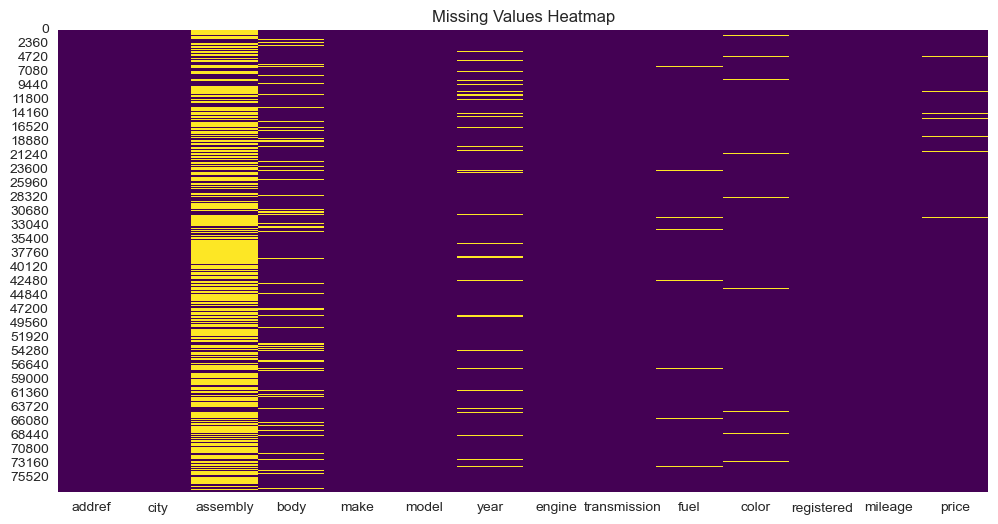

In [4]:
# Cell 3: Missing values heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.savefig('../reports/figures/missing_heatmap.png', dpi=150)
plt.show()


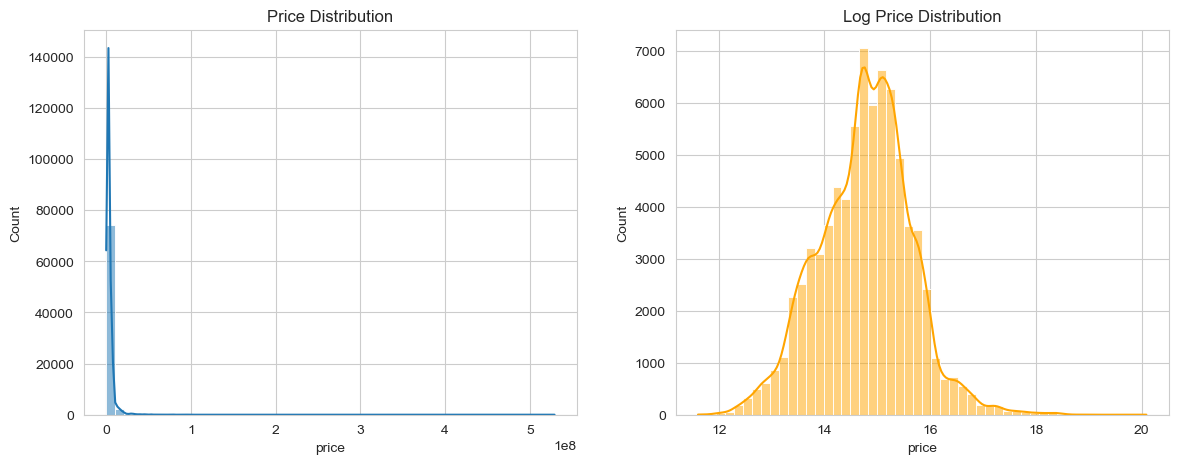

In [5]:
# Cell 4: Price distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['price'], bins=50, ax=axes[0], kde=True)
axes[0].set_title('Price Distribution')
sns.histplot(np.log1p(df['price']), bins=50, ax=axes[1], kde=True, color='orange')
axes[1].set_title('Log Price Distribution')
plt.savefig('../reports/figures/price_dist.png', dpi=150)

In [6]:
# Cell 5: Top 10 makes
top_makes = df['make'].value_counts().head(10)
px.bar(top_makes, title='Top 10 Car Makes in Pakistan',
       labels={'value': 'Count', 'index': 'Make'}).show()


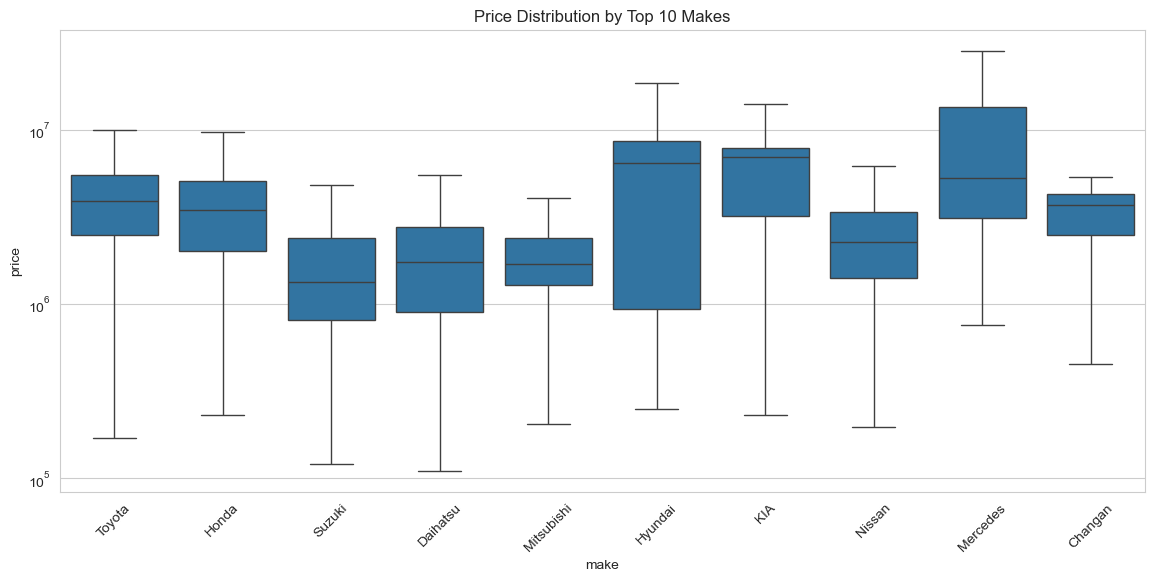

In [7]:
# Cell 6: Price by make (boxplot)
top_make_list = top_makes.index.tolist()
plt.figure(figsize=(14, 6))
sns.boxplot(data=df[df['make'].isin(top_make_list)],
            x='make', y='price', showfliers=False)
plt.yscale('log')
plt.xticks(rotation=45)
plt.title('Price Distribution by Top 10 Makes')
plt.savefig('../reports/figures/price_by_make.png', dpi=150)


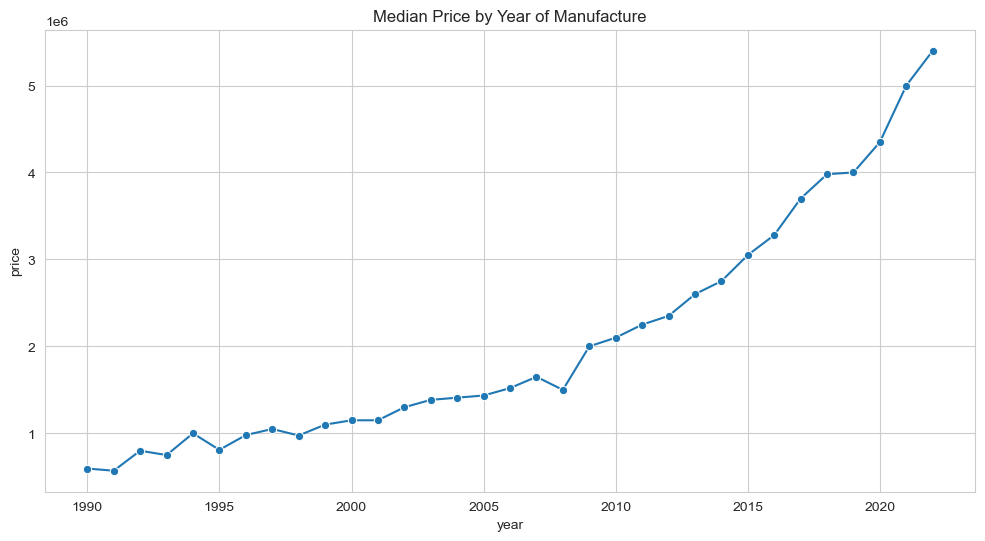

In [8]:
# Cell 7: Year vs Price trend
plt.figure(figsize=(12, 6))
yearly = df.groupby('year')['price'].median().reset_index()
sns.lineplot(data=yearly, x='year', y='price', marker='o')
plt.title('Median Price by Year of Manufacture')
plt.savefig('../reports/figures/year_vs_price.png', dpi=150)


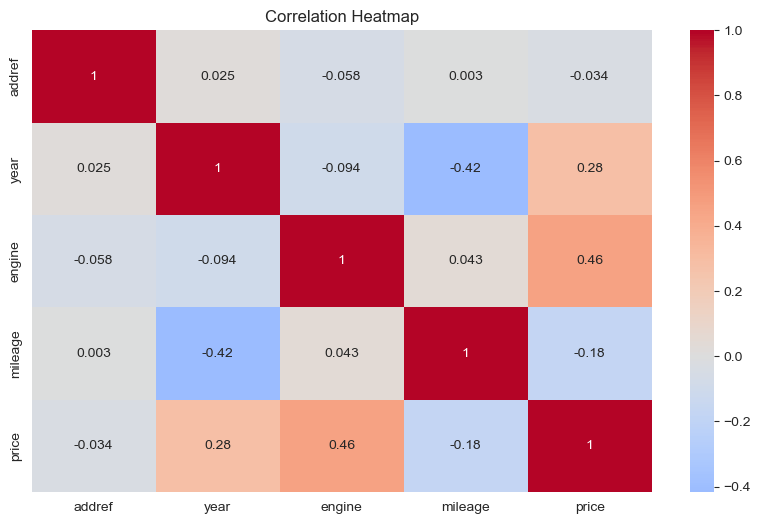

In [9]:
# Cell 8: Correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.select_dtypes(include=np.number).corr(),
            annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.savefig('../reports/figures/correlation.png', dpi=150)


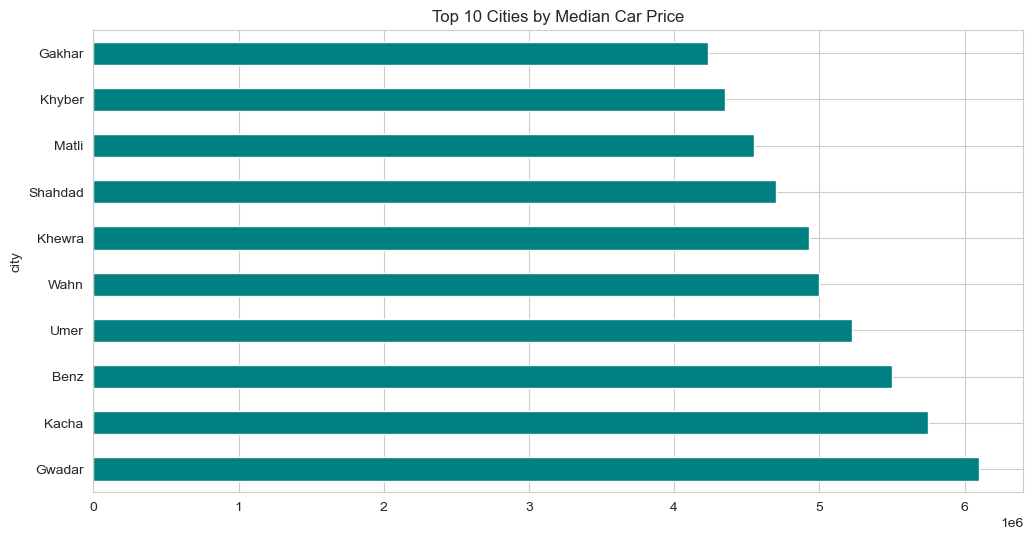

In [10]:
# Cell 9: City-wise price
city_price = df.groupby('city')['price'].median().sort_values(ascending=False).head(10)
city_price.plot(kind='barh', color='teal')
plt.title('Top 10 Cities by Median Car Price')
plt.savefig('../reports/figures/city_price.png', dpi=150)


